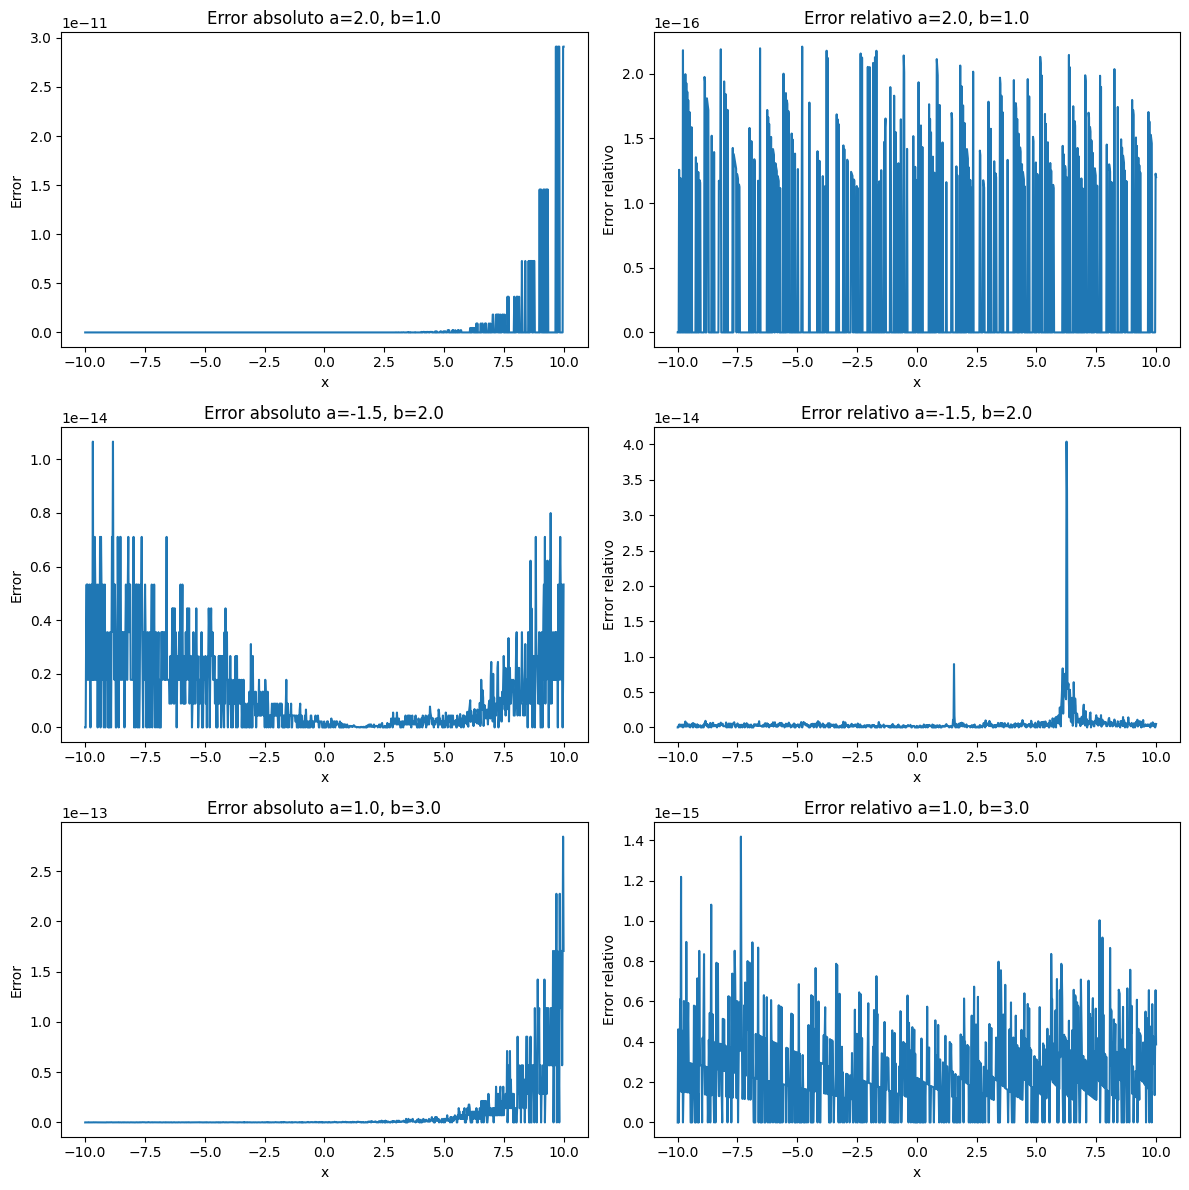

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath
import scipy.special

mpmath.mp.dps = 50  # Precisión alta con mpmath

x_values = np.linspace(-10, 10, 1000)

# Conjuntos de parámetros (a, b) con diferentes características
parametros = [
    (2.0, 1.0),      # a > b, ambos positivos
    (-1.5, 2.0),     # a negativo, b positivo
    (1.0, 3.0),      # a < b, ambos positivos
]

fig, axes = plt.subplots(len(parametros), 2, figsize=(12, 4 * len(parametros)))

for i, (a, b) in enumerate(parametros):
    resultados_mpmath = [mpmath.hyp1f1(a, b, x) for x in x_values]
    resultados_mpmath_float = [float(val.real) for val in resultados_mpmath]
    resultados_scipy = scipy.special.hyp1f1(a, b, x_values)

    error_absoluto = np.abs(np.array(resultados_mpmath_float) - resultados_scipy)
    error_relativo = error_absoluto / (np.abs(resultados_mpmath_float) + 1e-12)

    axes[i, 0].plot(x_values, error_absoluto)
    axes[i, 0].set_title(f'Error absoluto a={a}, b={b}')
    axes[i, 0].set_xlabel('x')
    axes[i, 0].set_ylabel('Error')

    axes[i, 1].plot(x_values, error_relativo)
    axes[i, 1].set_title(f'Error relativo a={a}, b={b}')
    axes[i, 1].set_xlabel('x')
    axes[i, 1].set_ylabel('Error relativo')

plt.tight_layout()
plt.show()


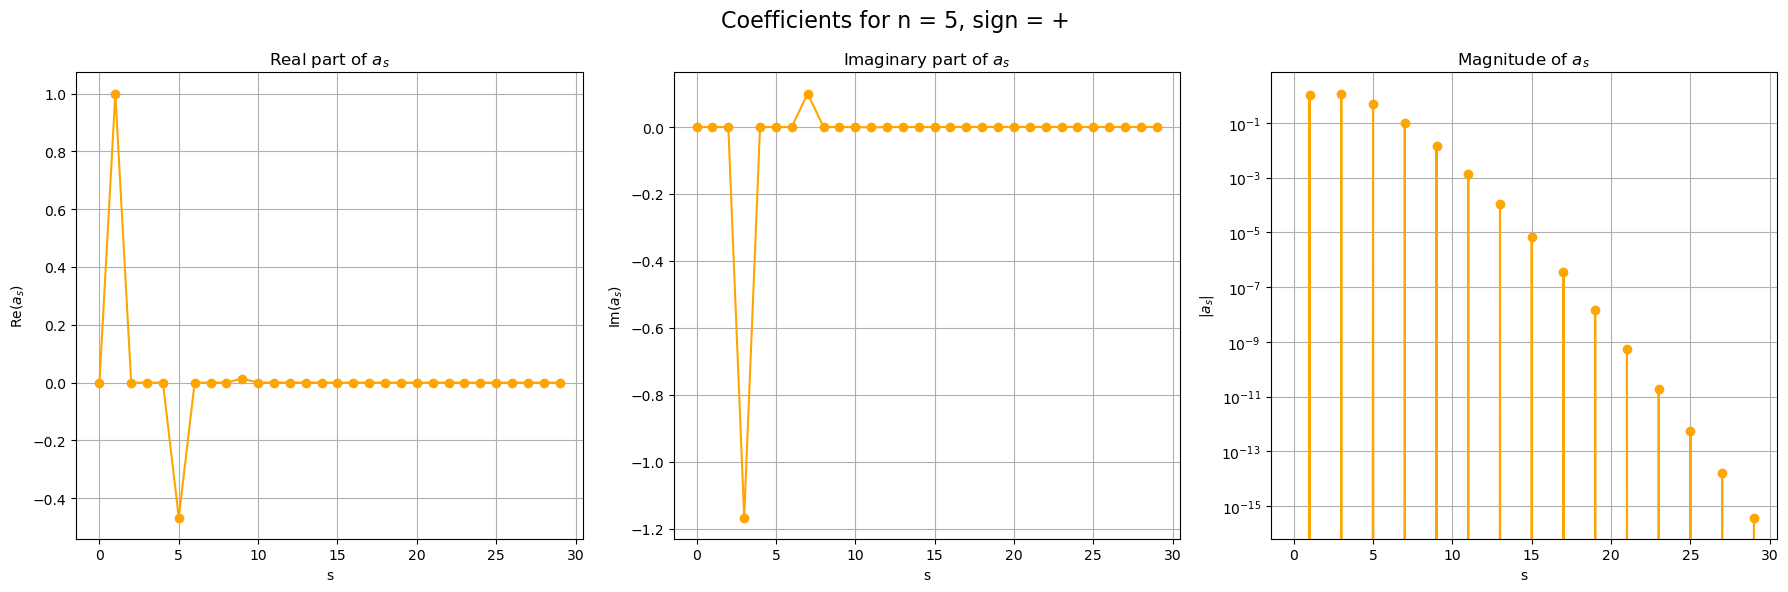

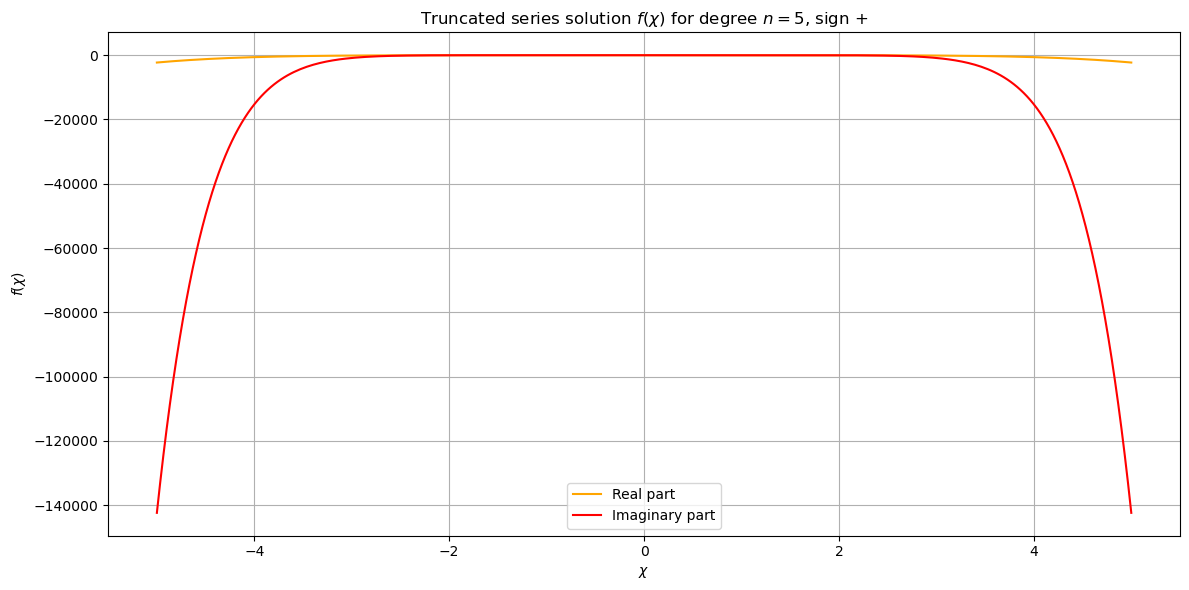

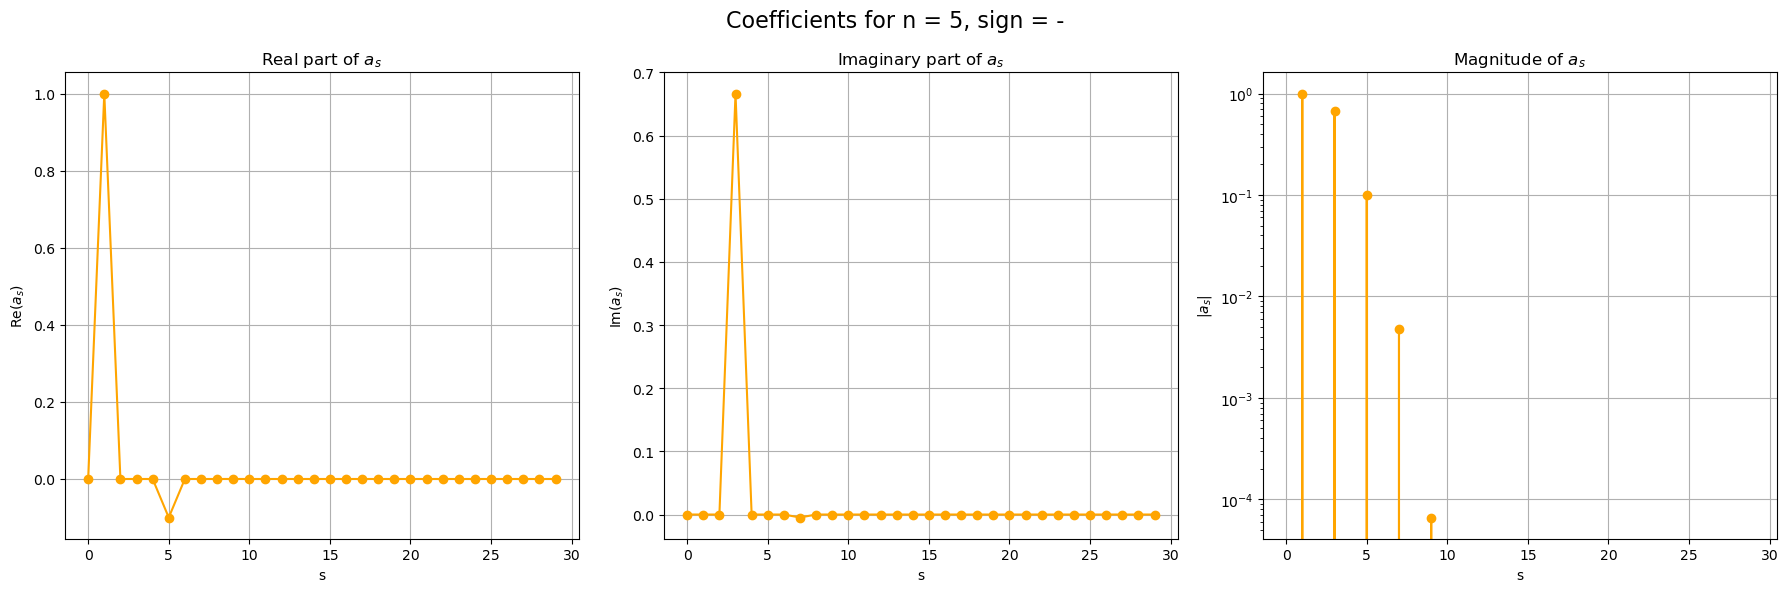

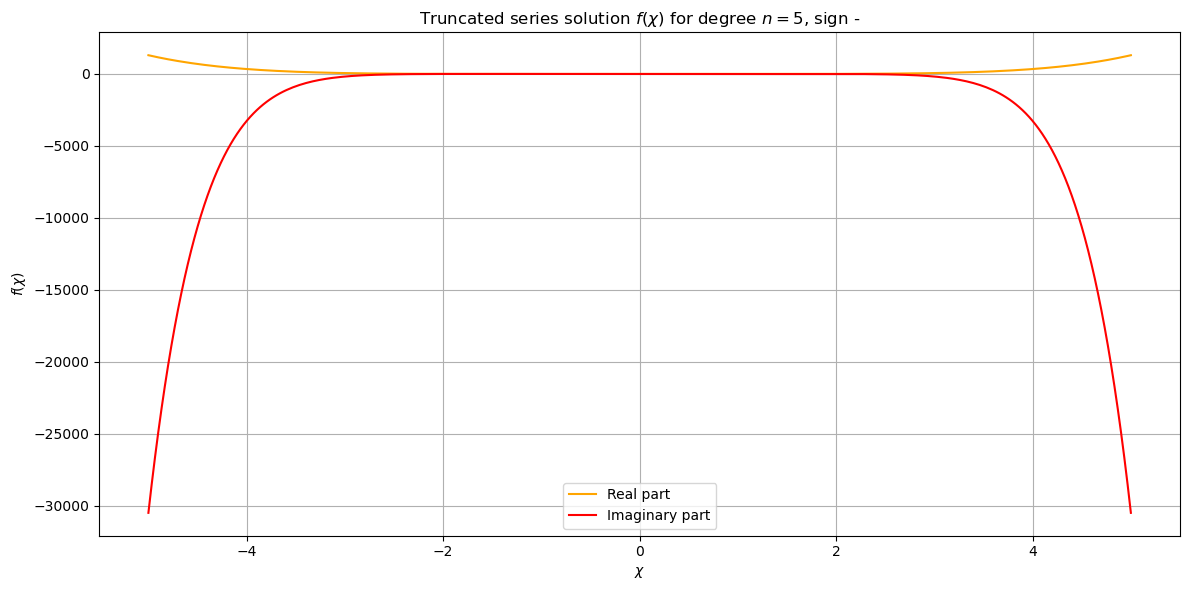

In [4]:
import numpy as np
import matplotlib.pyplot as plt

n = 5

def compute_coefficients(n, sign='+', max_terms=30):
    if sign == '+':
        a_trunc = -1j * (n + 0.5)
    else:
        a_trunc = 1j * (n + 0.5)

    a = np.zeros(max_terms, dtype=complex) #odd parity 
    a[0] = 0
    a[1] = 1

    for s in range(1, max_terms - 1):
        numerator = (1j*s/2 + 1j/2 - a_trunc)

        a[s + 1] = -a[s - 1] * numerator / ((s + 1) * s)

    return a

def plot_coefficients(a, n, sign):
    s_vals = np.arange(len(a))

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'Coefficients for n = {n}, sign = {sign}', fontsize=16)

    axes[0].plot(s_vals, np.real(a), 'o-', color='orange')
    axes[0].set_title('Real part of $a_s$')
    axes[0].set_xlabel('s')
    axes[0].set_ylabel('Re($a_s$)')
    axes[0].grid(True)

    axes[1].plot(s_vals, np.imag(a), 'o-', color='orange')
    axes[1].set_title('Imaginary part of $a_s$')
    axes[1].set_xlabel('s')
    axes[1].set_ylabel('Im($a_s$)')
    axes[1].grid(True)

    axes[2].plot(s_vals, np.abs(a), 'o-', color='orange')
    axes[2].set_yscale('log')
    axes[2].set_title('Magnitude of $a_s$')
    axes[2].set_xlabel('s')
    axes[2].set_ylabel('|$a_s$|')
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

def plot_truncated_series(a, n, sign):
    chi = np.linspace(-5, 5, 300)
    f_chi = np.zeros_like(chi, dtype=complex)
    for s in range(n + 1):
        f_chi += a[s] * (1j * chi**2 / 2) ** s

    plt.figure(figsize=(12, 6))
    plt.plot(chi, np.real(f_chi), label='Real part', color='orange')
    plt.plot(chi, np.imag(f_chi), label='Imaginary part', color='red')
    plt.title(f'Truncated series solution $f(\\chi)$ for degree $n={n}$, sign {sign}')
    plt.xlabel('$\\chi$')
    plt.ylabel('$f(\\chi)$')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

for sign in ['+', '-']:
    coeffs = compute_coefficients(n, sign=sign)
    plot_coefficients(coeffs, n, sign)
    plot_truncated_series(coeffs, n, sign)


In [17]:
import sympy as sp

def build_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, N, 2):  # s = 0,2,...,2N-2
            num = sp.I*(2*s + 1)/2 - sp.I*(2*N + 1)/2   # + first term, − eigen term
            den = (s + 2)*(s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, N, 2):  # s = 1,3,...,2N-3
            num = sp.I*(2*s + 1)/2 - sp.I*(2*N + 1)/2   # + first term, − eigen term
            den = (s + 2)*(s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])

    return coeffs, leading

def normalized_coeffs_sympy(N):
    coeffs, leading = build_coeffs_sympy(N)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs], leading

def poly_string_sympy(N, var="x"):
    coeffs_norm, leading = normalized_coeffs_sympy(N)
    leading_name = 'a0' if N % 2 == 0 else 'a1'
    terms = []
    for s, cs in enumerate(coeffs_norm):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(var if s == 1 else "1")
        else:
            terms.append(f"({sp.simplify(cs)})*{var}**{s}")
    return (f"f_{N}({var}) = {leading_name} * (" + " + ".join(terms) + ")").replace("I","i")

if __name__ == "__main__":
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


f_1(x) = a1 * (x)
f_2(x) = a0 * (1 + (-i)*x**2)
f_3(x) = a1 * (x + (-i/3)*x**3)
f_4(x) = a0 * (1 + (-2*i)*x**2 + (-1/3)*x**4)
f_5(x) = a1 * (x + (-2*i/3)*x**3 + (-1/15)*x**5)
f_6(x) = a0 * (1 + (-3*i)*x**2 + (-1)*x**4 + (i/15)*x**6)
f_7(x) = a1 * (x + (-i)*x**3 + (-1/5)*x**5 + (i/105)*x**7)


In [18]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = -sp.I * (2*s + 1) / 2 + sp.I * (2*N + 1) / 2
            den = (s + 2) * (s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 1) / 2 + sp.I * (2*N + 1) / 2
            den = (s + 2) * (s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)})*{var}**{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading} * ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


f_1(x) = a1 * (x)
f_2(x) = a0 * (1 + (i)*x**2)
f_3(x) = a1 * (x + (i/3)*x**3)
f_4(x) = a0 * (1 + (2*i)*x**2 + (-1/3)*x**4)
f_5(x) = a1 * (x + (2*i/3)*x**3 + (-1/15)*x**5)
f_6(x) = a0 * (1 + (3*i)*x**2 + (-1)*x**4 + (-i/15)*x**6)
f_7(x) = a1 * (x + (i)*x**3 + (-1/5)*x**5 + (-i/105)*x**7)


In [19]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = -sp.I * (2*s + 3) / 2 + sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 3) / 2 + sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)})*{var}**{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading} * ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


f_1(x) = a1 * (x)
f_2(x) = a0 * (1 + (i/3)*x**2)
f_3(x) = a1 * (x + (i/6)*x**3)
f_4(x) = a0 * (1 + (2*i/3)*x**2 + (-1/15)*x**4)
f_5(x) = a1 * (x + (i/3)*x**3 + (-1/45)*x**5)
f_6(x) = a0 * (1 + (i)*x**2 + (-1/5)*x**4 + (-i/105)*x**6)
f_7(x) = a1 * (x + (i/2)*x**3 + (-1/15)*x**5 + (-i/420)*x**7)


In [20]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = sp.I * (2*s + 3) / 2 - sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = sp.I * (2*s + 3) / 2 - sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)})*{var}**{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading} * ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


f_1(x) = a1 * (x)
f_2(x) = a0 * (1 + (-i/3)*x**2)
f_3(x) = a1 * (x + (-i/6)*x**3)
f_4(x) = a0 * (1 + (-2*i/3)*x**2 + (-1/15)*x**4)
f_5(x) = a1 * (x + (-i/3)*x**3 + (-1/45)*x**5)
f_6(x) = a0 * (1 + (-i)*x**2 + (-1/5)*x**4 + (i/105)*x**6)
f_7(x) = a1 * (x + (-i/2)*x**3 + (-1/15)*x**5 + (i/420)*x**7)
